<a href="https://colab.research.google.com/github/ConanBoran/child-mortality-report/blob/main/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
title: "Unequal Progress in Child Mortality (Ages 5–9)"
author: "Conan Boran"
format:
  html:
    theme: cosmo
    toc: true
    toc-depth: 2
    embed-resources: true
    code-fold: true
execute:
  warning: false
  message: false
---

In [26]:
#| echo: false
#| warning: false
#| message: false

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
#| warning: false
#| message: false

!pip install polars plotnine geopandas

This report examines global changes in child mortality between 1990 and 2023 using UNICEF data.  
Although mortality rates have declined over time, progress has not been equal across countries.

The report focuses on three questions:

- Has child mortality improved globally?
- Which countries achieved the biggest reductions?
- Is stronger progress linked to wider development outcomes?

Rather than focusing only on the latest mortality level, this analysis emphasises **change over time**.  
This makes it possible to compare not only whether countries improved, but **how much** they improved.


In [28]:
#| echo: false
#| warning: false
#| message: false

uploaded = files.upload()

Saving unicef_metadata (2).csv to unicef_metadata (2) (2).csv
Saving unicef_indicator_2 (1).csv to unicef_indicator_2 (1) (2).csv


In [29]:
#| warning: false
#| message: false

import polars as pl
import geopandas as gp
from plotnine import *
from google.colab import files

## Data Loading

The UNICEF indicator file and metadata file were loaded using `polars`. The metadata file was used to add contextual development information to the mortality dataset.

In [30]:
#| warning: false
#| message: false

indicator = pl.read_csv("unicef_indicator_2 (1).csv")
metadata = pl.read_csv("unicef_metadata (2).csv")


## Data Preparation

I filtered the UNICEF dataset to keep the total mortality rate for children aged 5–9.  
I selected the most relevant variables and renamed them to make the dataset easier to analyse.

I then joined the indicator data with metadata in order to include life expectancy as a broader development variable.  
This allows the report to move beyond description and explore whether mortality improvement is linked to wider social progress.

In [31]:
#| warning: false
#| message: false

data = (
    indicator
    .filter(pl.col("sex") == "Total")
    .select(
        pl.col("country"),
        pl.col("alpha_3_code"),
        pl.col("time_period").alias("year"),
        pl.col("obs_value").alias("mortality_rate")
    )
)


Before creating the visualisations, I checked the time range, country coverage, and missing values.  
This confirmed that the dataset was suitable for comparing long-term changes between 1990 and 2023.

I then joined the UNICEF indicator data with metadata to include life expectancy as a wider development variable.

In [32]:
meta_small = (
    metadata
    .select(
        pl.col("country"),
        pl.col("year"),
        pl.col("Life expectancy at birth, total (years)").alias("life_expectancy")
    )
)

data = data.join(meta_small, on=["country", "year"], how="left")



In [33]:
#| echo: false
#| warning: false
#| message: false

data.select(
    pl.len().alias("rows"),
    pl.col("country").n_unique().alias("countries"),
    pl.col("year").min().alias("first_year"),
    pl.col("year").max().alias("last_year"),
    pl.col("mortality_rate").is_null().sum().alias("missing_mortality"),
    pl.col("life_expectancy").is_null().sum().alias("missing_life_expectancy")
)

rows,countries,first_year,last_year,missing_mortality,missing_life_expectancy
u32,u32,i64,i64,u32,u32
6766,199,1990,2023,0,170


In [34]:
#| warning: false
#| message: false

time_data = (
    data
    .group_by("year")
    .agg(
        pl.col("mortality_rate").mean().alias("avg_mortality")
    )
    .sort("year")
)



## Global Progress Over Time

The time-series chart shows a clear long-term decline in the global average mortality rate for children aged 5–9 between 1990 and 2023.  
This indicates substantial overall progress in child survival.

However, a global average can hide major differences between countries.  
For that reason, the next part of the report focuses on **unequal progress**, rather than only the global trend.

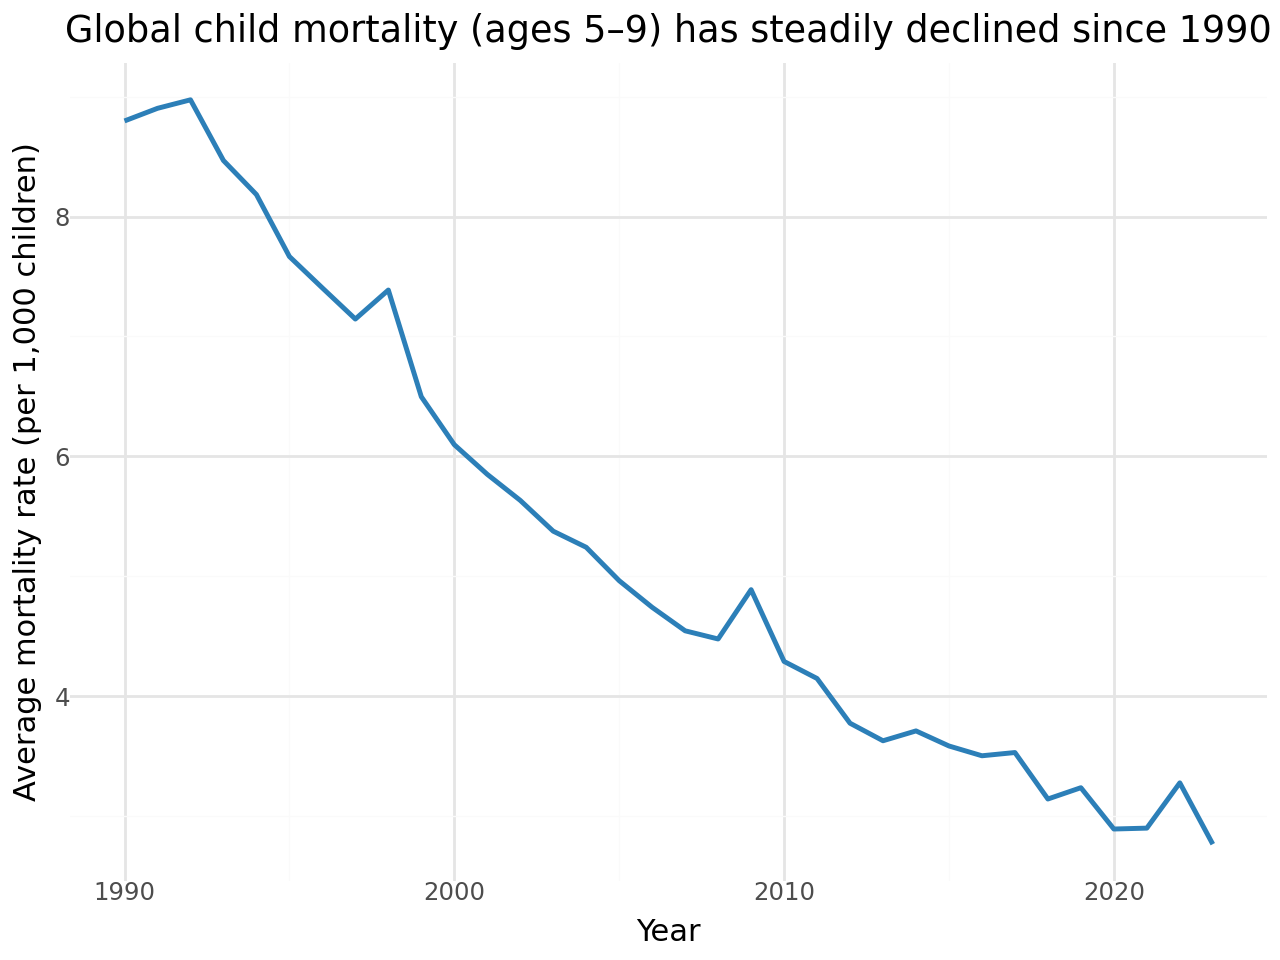

In [35]:
##| label: fig-time-series
#| fig-cap: "Global average mortality rate for children aged 5–9 over time."
#| fig-width: 8
#| fig-height: 4.5

(
    ggplot(time_data.to_pandas())
    + aes(x="year", y="avg_mortality")
    + geom_line(color="#2c7fb8", size=1)
    + labs(
        title="Global child mortality (ages 5–9) has steadily declined since 1990",
        x="Year",
        y="Average mortality rate (per 1,000 children)"
    )
    + theme_minimal()
)

In [36]:
change_data = (
    data
    .filter(pl.col("year").is_in([1990, 2023]))
    .pivot(
        values="mortality_rate",
        index=["country", "alpha_3_code"],
        on="year"
    )
    .with_columns(
        (pl.col("2023") - pl.col("1990")).alias("change")
    )
)


## Unequal Progress Across Countries

To identify which countries made the greatest progress, I calculated the change in mortality rates between 1990 and 2023.

A more negative value indicates a larger reduction in mortality, and therefore stronger improvement over time. This allows countries to be ranked based on the extent of their progress rather than their current mortality levels.

In [37]:
#| echo: false
#| warning: false
#| message: false

top_improvers = (
    change_data
    .sort("change")
    .head(10)
)

top_improvers

country,alpha_3_code,1990,2023,change
str,str,f64,f64,f64
"""South Sudan""","""SSD""",89.428394,13.748889,-75.679505
"""Ethiopia""","""ETH""",51.950814,3.834238,-48.116576
"""Rwanda""","""RWA""",40.454208,2.704746,-37.749462
"""Mozambique""","""MOZ""",40.555336,4.967369,-35.587967
"""Guinea-Bissau""","""GNB""",37.119856,6.521655,-30.598201
"""Angola""","""AGO""",37.688768,8.705866,-28.982902
"""Burundi""","""BDI""",38.292853,9.954832,-28.338021
"""Niger""","""NER""",46.522571,18.256536,-28.266035
"""Eritrea""","""ERI""",30.245344,3.355755,-26.889589


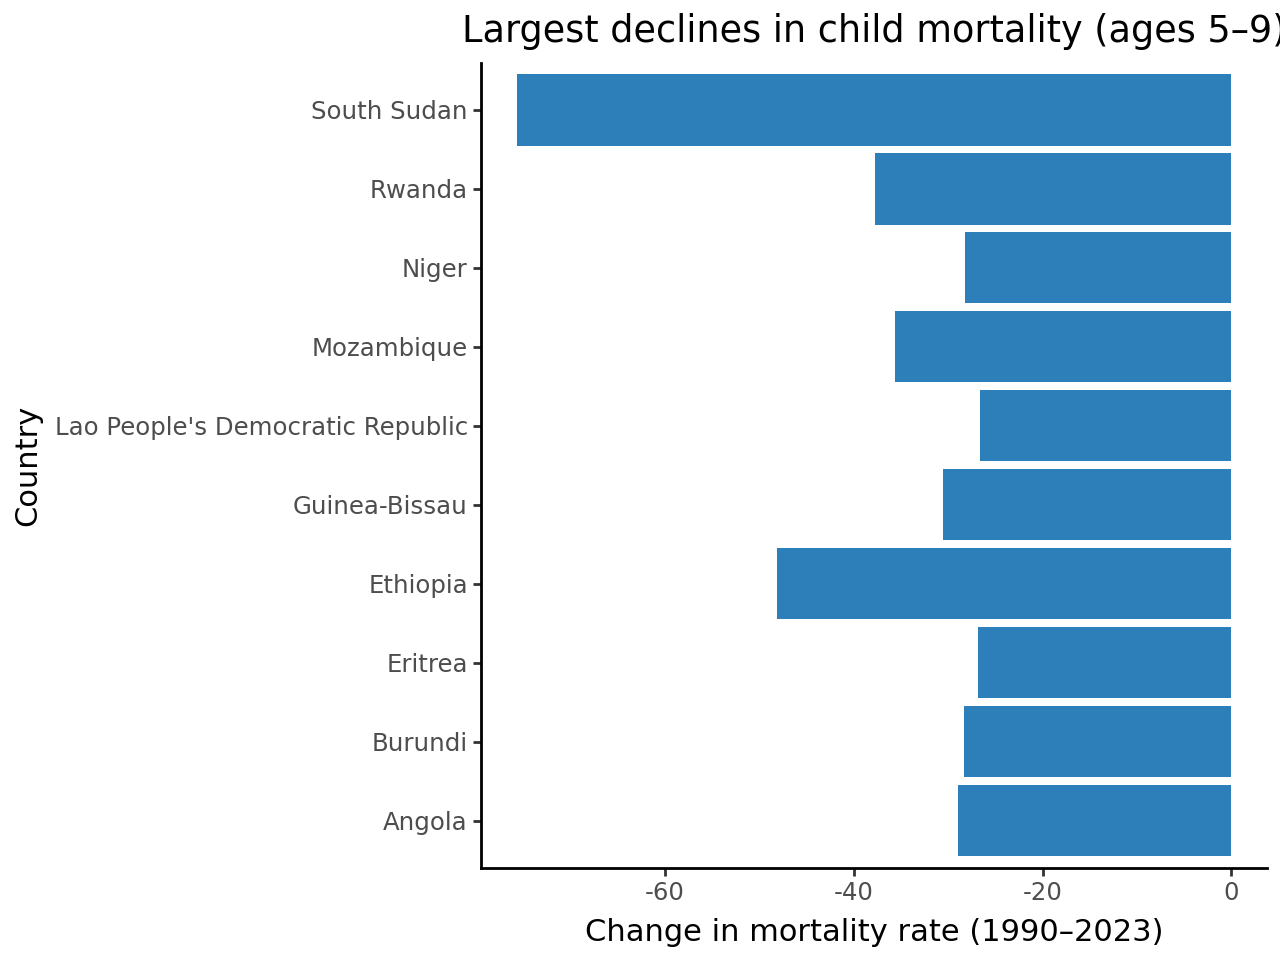

In [42]:
#| label: fig-bar
#| fig-cap: "Countries with the largest reduction in child mortality between 1990 and 2023."
#| fig-width: 9
#| fig-height: 5.5

top_improvers_pd = top_improvers.to_pandas().sort_values("change")

(
    ggplot(top_improvers_pd)
    + aes(x="country", y="change")
    + geom_col(fill="#2c7fb8")
    + coord_flip()
    + labs(
        title="Largest declines in child mortality (ages 5–9)",
        x="Country",
        y="Change in mortality rate (1990–2023)"
    )
    + theme_classic()
)

## Progress and Development

The scatterplot compares mortality improvement with life expectancy in 2023.  
The fitted linear regression line suggests that countries with higher life expectancy tend to show stronger reductions in child mortality.

This does not prove causation, but it does suggest that progress in child survival is closely linked to broader development outcomes.  
In other words, mortality improvement appears to be part of a wider pattern of social and health progress.

In [43]:
scatter_data = (
    change_data
    .join(
        data
        .filter(pl.col("year") == 2023)
        .select("country", "life_expectancy"),
        on="country",
        how="left"
    )
    .drop_nulls()
)

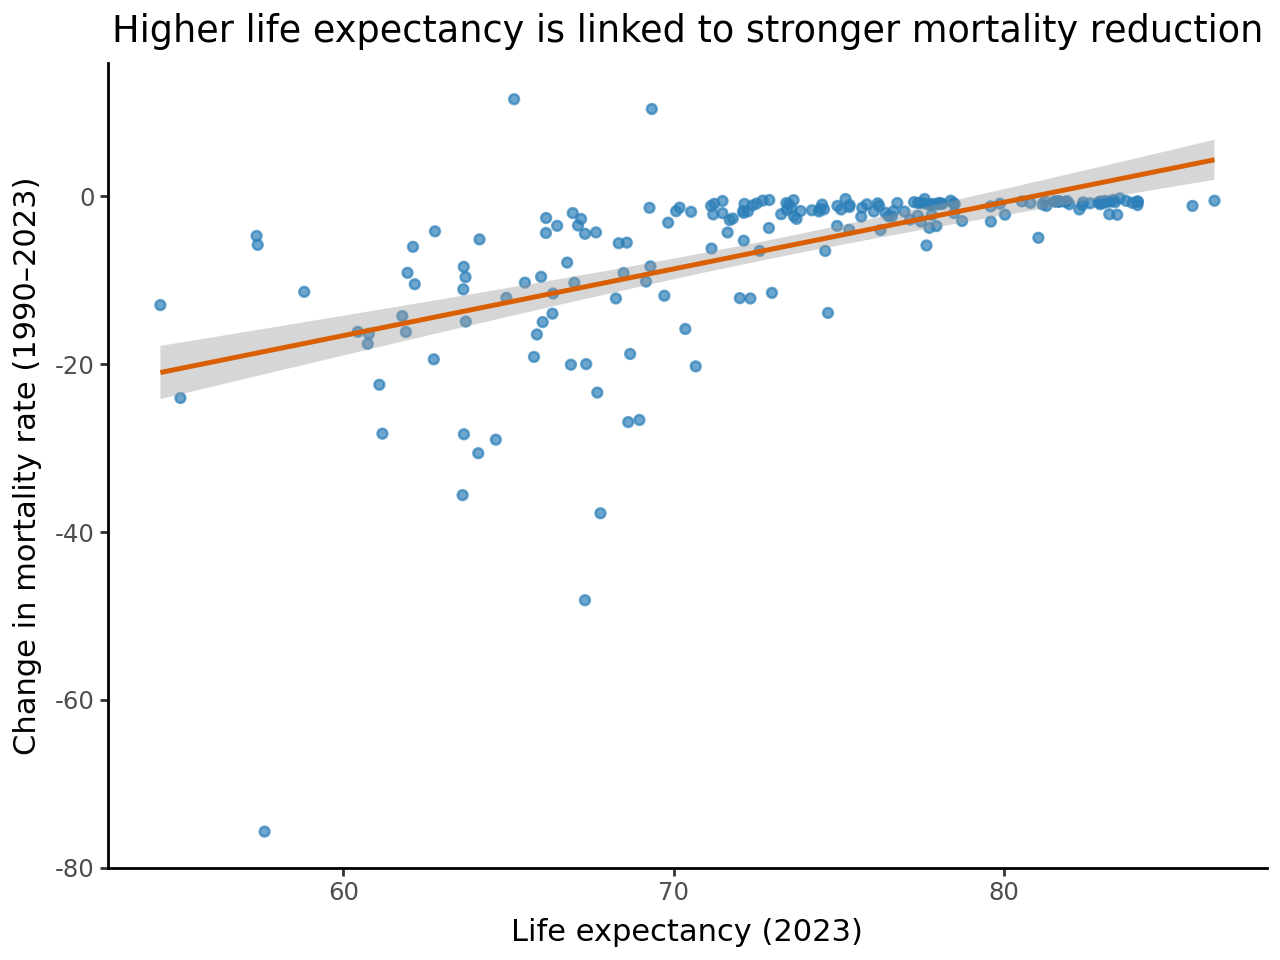

In [45]:
#| label: fig-scatter
#| fig-cap: "Relationship between mortality improvement and life expectancy."
#| fig-width: 8
#| fig-height: 5

(
    ggplot(scatter_data.to_pandas())
    + aes(x="life_expectancy", y="change")
    + geom_point(color="#2c7fb8", alpha=0.7)
    + geom_smooth(method="lm", color="#d95f02")
    + labs(
        title="Higher life expectancy is linked to stronger mortality reduction",
        x="Life expectancy (2023)",
        y="Change in mortality rate (1990–2023)"
    )
    + theme_classic()
)

## A Global View of Unequal Progress

The world map highlights the geographical unevenness of mortality improvement between 1990 and 2023.  
Large reductions appear in some parts of the world, while other countries show more limited progress.

This visual reinforces the central argument of the report: although child mortality has declined globally, the scale of improvement has differed greatly across countries.  
Global progress, therefore, should not be confused with equal progress.

In [46]:
#| echo: false
#| warning: false
#| message: false

world = gp.read_file(
    "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/world-administrative-boundaries/exports/shp"
)

In [49]:
map_data = world.merge(
    change_data.to_pandas(),
    left_on="iso3",
    right_on="alpha_3_code",
    how="left"
)

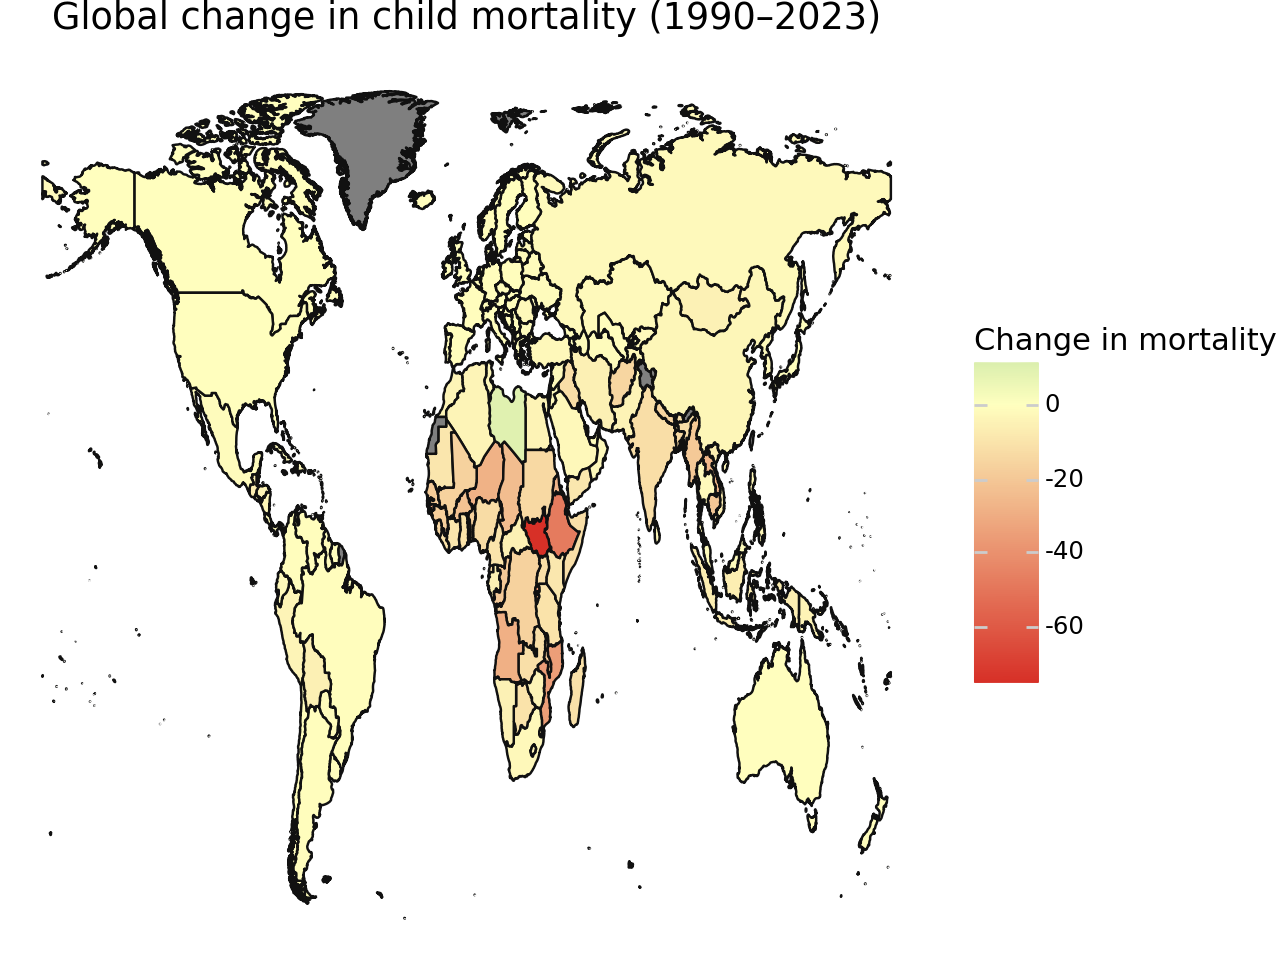

In [51]:
#| label: fig-map
#| fig-cap: "Global change in child mortality between 1990 and 2023."
#| fig-width: 10
#| fig-height: 6

(
    ggplot(map_data)
    + aes(fill="change")
    + geom_map()
    + scale_fill_gradient2(
        low="#d73027",
        mid="#ffffbf",
        high="#1a9850",
        midpoint=0
    )
    + labs(
        title="Global change in child mortality (1990–2023)",
        fill="Change in mortality"
    )
    + theme_void()
)

## Limitations

This analysis is based on available UNICEF data and may be affected by differences in reporting quality across countries.  
Some countries may also have missing values or measurement differences that affect comparability.

In addition, the report focuses on mortality and life expectancy only.  
It does not directly examine other factors such as healthcare access, education, conflict, or income, which may also influence child survival outcomes.

As a result, the relationships identified in this report should be interpreted as associations rather than causal effects.

## Conclusion

This report shows that child mortality among children aged 5–9 declined substantially between 1990 and 2023, indicating strong overall global progress.

However, the analysis also shows that progress was not evenly distributed.  
Some countries achieved very large reductions, while others improved more slowly.

Overall, the key finding is not only that progress occurred, but that it was highly uneven across countries.

These findings highlight that improving child survival is not only a medical issue, but also a broader development challenge requiring sustained investment across countries.

## Data Sources

Data used in this report come from the UNICEF child mortality indicator dataset and the accompanying metadata file provided for the assignment.

In [55]:
!quarto render report.ipynb

/bin/bash: line 1: quarto: command not found


In [56]:
!cp report.html "/content/drive/MyDrive/Colab Notebooks/report.html"

cp: cannot stat 'report.html': No such file or directory
